Fidelity = 0.9999999873863445


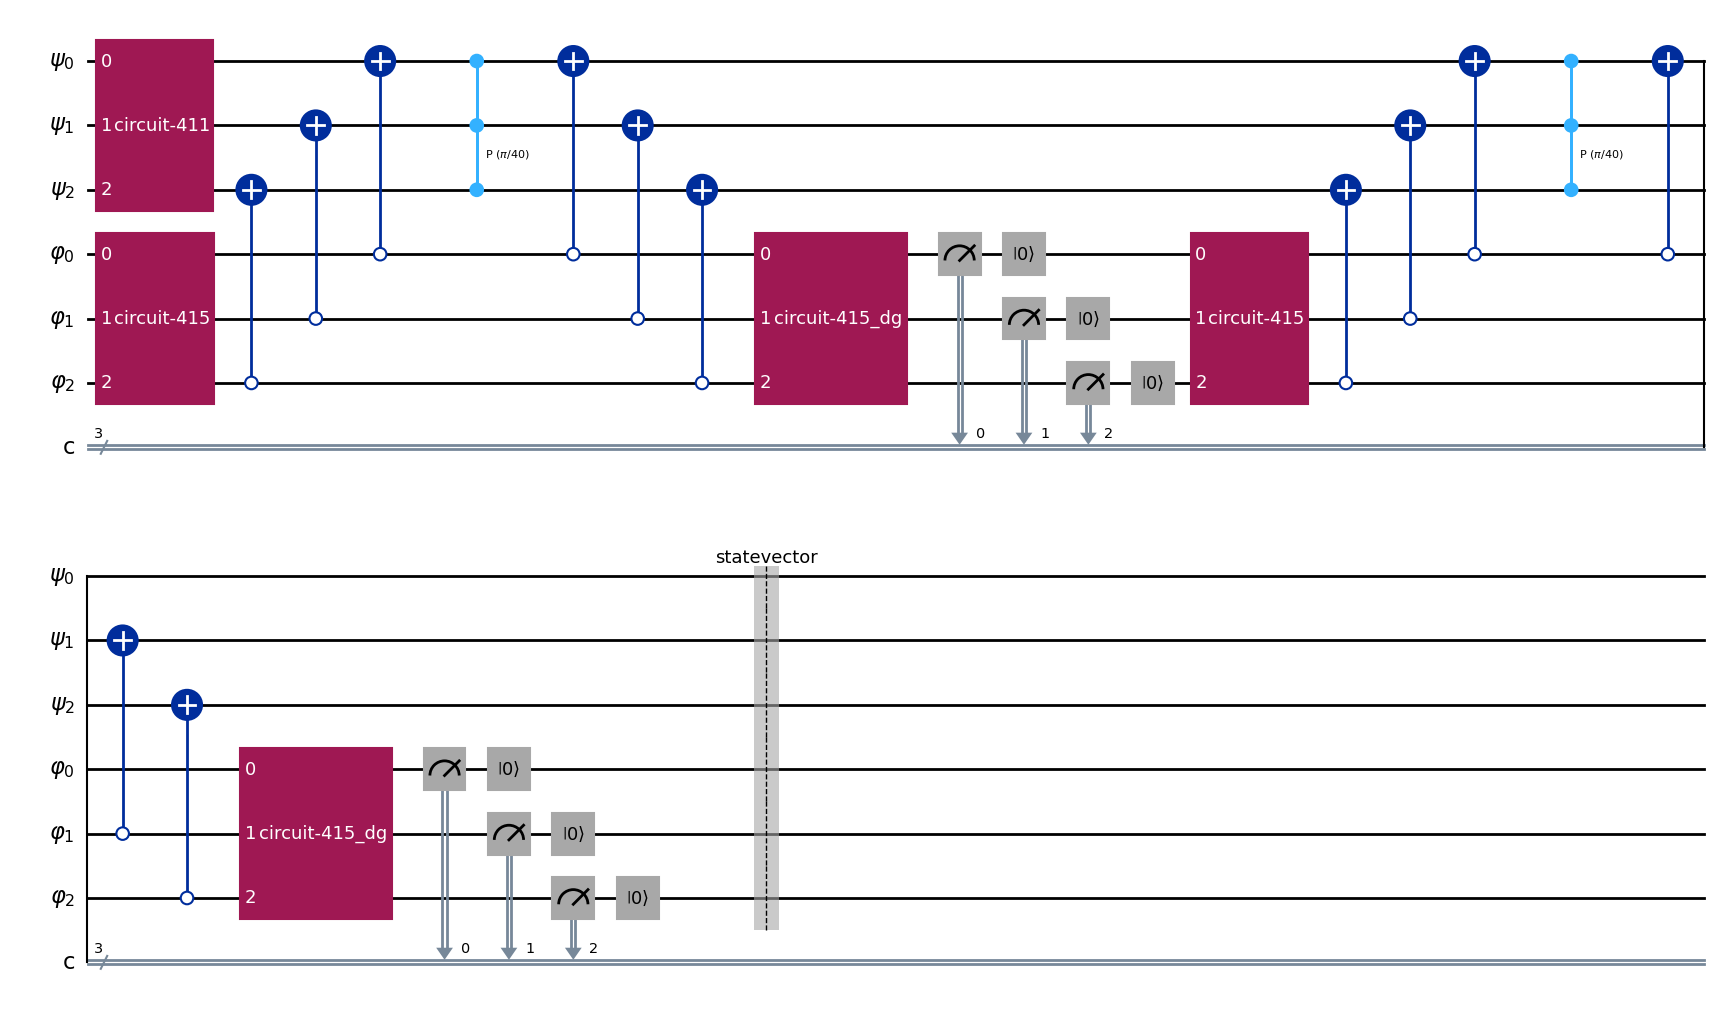

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import partial_trace, DensityMatrix, state_fidelity

from gaussian_beam import simulate_gaussian
from grathing import generate_phi


# ----------------------------
# Parameters
# ----------------------------
n = 3
N = 2**n

Lx = 20e-6
w0 = 2e-6
wavelength = 633e-9

z_total = 0.05
z_grating = 0.02

Lambda = 2e-6
duty = 0.50
d0 = 100e-9
h = 50e-9
n_refr = 1.5

delta = np.pi / 40
m = 2
number_of_layers = 2


# ----------------------------
# Primary state ψ: Gaussian propagated to grating plane
# ----------------------------
x, dx, psi0, psi_at_grating = simulate_gaussian(
    n_qubits=n,
    Lx=Lx,
    w0=w0,
    wavelength=wavelength,
    z=z_grating
)

psi = psi_at_grating / np.linalg.norm(psi_at_grating)


# ----------------------------
# Ancilla state φ: grating profile
# ----------------------------
x_phi, f, phi, alpha = generate_phi(
    L=Lx,
    Nx=N,
    lam=wavelength,
    n=n_refr,
    Lambda=Lambda,
    duty=duty,
    d0=d0,
    h=h
)

phi = np.asarray(phi, dtype=complex)
phi = phi / np.linalg.norm(phi)


# ----------------------------
# MPS initializer circuits
# ----------------------------
psi_state = QuantumState.from_dense_data(data=psi, normalize=True)
phi_state = QuantumState.from_dense_data(data=phi, normalize=True)

U_psi = psi_state.generate_mps_initializer_circuit(
    number_of_layers=number_of_layers
)

U_phi = phi_state.generate_mps_initializer_circuit(
    number_of_layers=number_of_layers
)

U_phi_dagger = U_phi.inverse()


# ----------------------------
# Protocol
# ----------------------------
def run_protocol(m, delta, return_state=False):
    psi_reg = QuantumRegister(n, name="ψ")
    phi_reg = QuantumRegister(n, name="φ")
    creg = ClassicalRegister(n, name="c")

    qc = QuantumCircuit(psi_reg, phi_reg, creg)

    qc.append(U_psi, psi_reg)
    qc.append(U_phi, phi_reg)

    for k in range(1, m + 1):

        # equality flag: ψ == φ
        for i in range(n):
            qc.cx(phi_reg[n - 1 - i], psi_reg[n - 1 - i], ctrl_state=0)

        # phase kick
        qc.mcp(delta, psi_reg[0:-1], psi_reg[-1])

        # uncompute flag
        for i in range(n):
            qc.cx(phi_reg[i], psi_reg[i], ctrl_state=0)

        # uncompute ancilla
        qc.append(U_phi_dagger, phi_reg)
        qc.measure(phi_reg, creg)
        qc.reset(phi_reg)

        if k < m:
            qc.append(U_phi, phi_reg)

    sim = AerSimulator(method="statevector")
    qc.save_statevector()

    result = sim.run(transpile(qc, sim)).result()
    full_state = result.get_statevector(qc)

    rho_psi = partial_trace(full_state, list(range(n, 2 * n)))

    psi_vec = np.asarray(psi, dtype=complex)
    psi_vec = psi_vec / np.linalg.norm(psi_vec)

    phi_vec = np.asarray(phi, dtype=complex)
    phi_vec = phi_vec / np.linalg.norm(phi_vec)

    phase_profile = np.exp(1j * delta * m * np.abs(phi_vec)**2)

    ideal_vec = psi_vec * phase_profile
    ideal_vec = ideal_vec / np.linalg.norm(ideal_vec)

    rho_ideal = DensityMatrix(ideal_vec)

    fid = state_fidelity(rho_psi, rho_ideal)

    if return_state:
        return fid, rho_psi, ideal_vec, qc

    return fid


fid, rho_psi, ideal_vec, qc = run_protocol(
    m=m,
    delta=delta,
    return_state=True
)

print("Fidelity =", fid)

qc.draw("mpl")

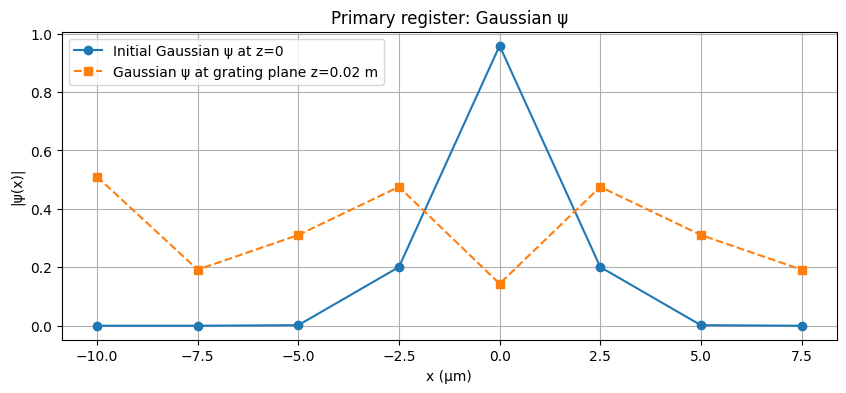

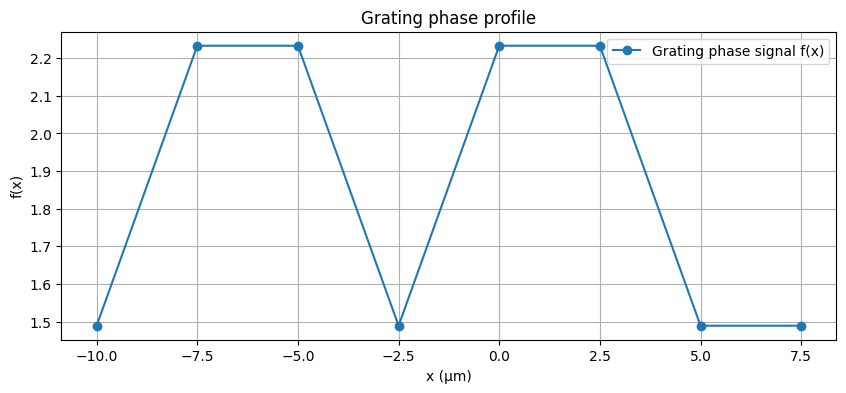

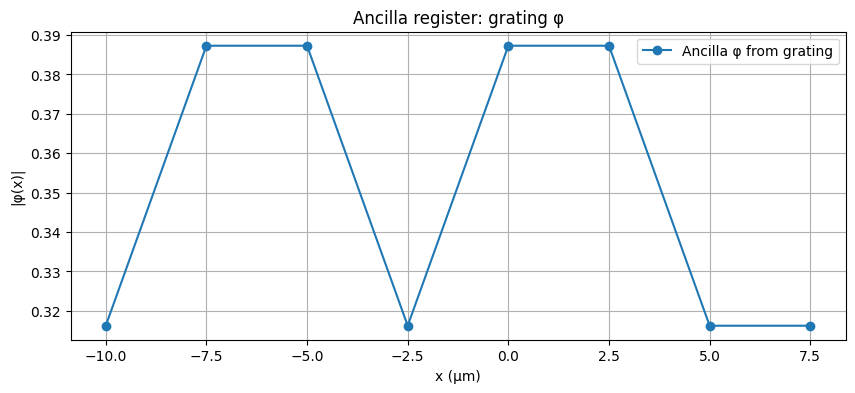

In [7]:
# ----------------------------
# Plot Gaussian ψ
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(x * 1e6, np.abs(psi0), "o-", label="Initial Gaussian ψ at z=0")
plt.plot(x * 1e6, np.abs(psi), "s--", label=f"Gaussian ψ at grating plane z={z_grating} m")
plt.xlabel("x (µm)")
plt.ylabel("|ψ(x)|")
plt.title("Primary register: Gaussian ψ")
plt.legend()
plt.grid(True)
plt.show()


# ----------------------------
# Plot grating f and ancilla φ
# ----------------------------
plt.figure(figsize=(10, 4))
plt.plot(x_phi * 1e6, f, "o-", label="Grating phase signal f(x)")
plt.xlabel("x (µm)")
plt.ylabel("f(x)")
plt.title("Grating phase profile")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(x_phi * 1e6, np.abs(phi), "o-", label="Ancilla φ from grating")
plt.xlabel("x (µm)")
plt.ylabel("|φ(x)|")
plt.title("Ancilla register: grating φ")
plt.legend()
plt.grid(True)
plt.show()

Example m=20, δ=0.00785: Fidelity=1.000000


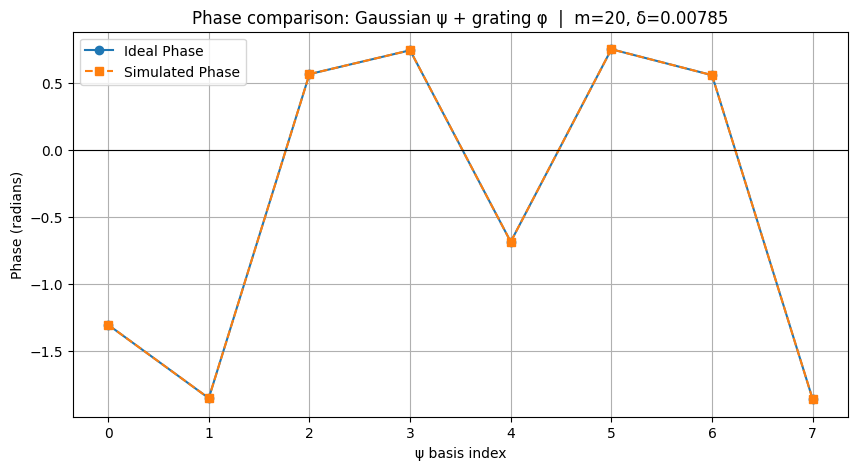

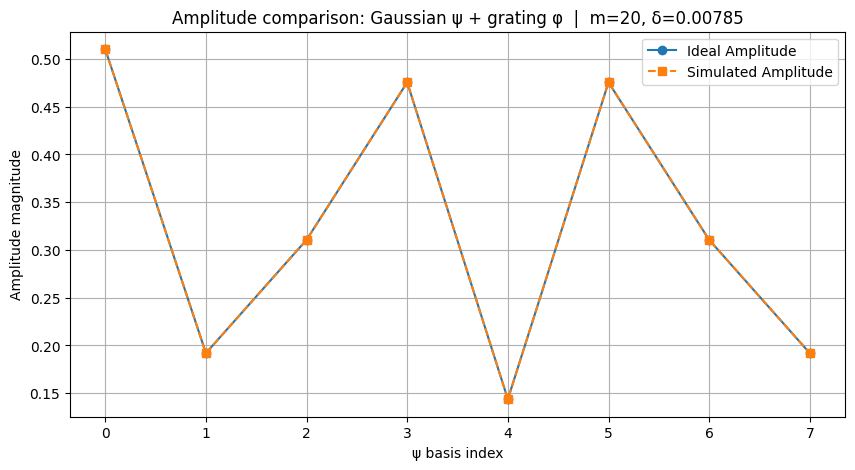

In [4]:
m_example = 20
delta_example = np.pi / 400

fid_ex, rho_psi, ideal_vec, qc = run_protocol(
    m_example,
    delta_example,
    return_state=True
)

vec_sim = np.array(rho_psi.to_statevector())

# --- Align global phase ---
global_phase = np.angle(np.vdot(ideal_vec, vec_sim))
vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

# --- Amplitudes and phases ---
amps_ideal = np.abs(ideal_vec)
amps_sim = np.abs(vec_sim_aligned)

phases_ideal = np.unwrap(np.angle(ideal_vec))
phases_sim = np.unwrap(np.angle(vec_sim_aligned))

print(f"Example m={m_example}, δ={delta_example:.5f}: Fidelity={fid_ex:.6f}")

# --- Phase comparison ---
plt.figure(figsize=(10, 5))
plt.plot(range(N), phases_ideal, "o-", label="Ideal Phase")
plt.plot(range(N), phases_sim, "s--", label="Simulated Phase")
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Phase (radians)")
plt.xlabel("ψ basis index")
plt.title(f"Phase comparison: Gaussian ψ + grating φ  |  m={m_example}, δ={delta_example:.5f}")
plt.legend()
plt.grid(True)
plt.show()

# --- Amplitude comparison ---
plt.figure(figsize=(10, 5))
plt.plot(range(N), amps_ideal, "o-", label="Ideal Amplitude")
plt.plot(range(N), amps_sim, "s--", label="Simulated Amplitude")
plt.ylabel("Amplitude magnitude")
plt.xlabel("ψ basis index")
plt.title(f"Amplitude comparison: Gaussian ψ + grating φ  |  m={m_example}, δ={delta_example:.5f}")
plt.legend()
plt.grid(True)
plt.show()